# 06 â€” Regression Model Comparison
Ridge Â· RandomForest Â· XGBoost Â· LightGBM Â· SVR Â· KNN with default hyperparams, 5-fold CV on train split. Primary metric: MAE.

In [1]:

import sys, os
from pathlib import Path
root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
import pandas as pd
from src.config import SPLITS_DIR, RESULTS_DIR, FEATURES, TARGETS_REG
from src.models import reg_models, REG_NAMES
from src.evaluate import evaluate_target, leaderboard_row

train = pd.read_csv(SPLITS_DIR / "train.csv")
X = train[FEATURES]
factories = reg_models()
rows = []
for target in TARGETS_REG:
    y = train[target]
    for name in REG_NAMES:
        scores = evaluate_target("reg", factories[name], X, y)
        row = leaderboard_row(name, target, "reg", scores)
        rows.append(row)
        print(target, name, "->", row["primary_metric"], row["primary_value"], flush=True)
reg_cv = pd.DataFrame(rows)
reg_cv.to_csv(RESULTS_DIR / "reg_baseline_cv.csv", index=False)
reg_cv.sort_values(["target", "mae_mean"])


next_cycle_length ridge -> mae 1.22345


next_cycle_length random_forest -> mae 1.21759


next_cycle_length xgboost -> mae 1.33991


next_cycle_length lightgbm -> mae 1.26114


next_cycle_length svr -> mae 1.24341


...

next_period_length xgboost -> mae 0.64317


next_period_length lightgbm -> mae 0.60056


next_period_length svr -> mae 0.59112


next_period_length knn -> mae 0.61701


,model,target,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,primary_metric,primary_value
1,random_forest,next_cycle_length,1.21759,0.02187,1.77032,0.03587,0.78722,0.00954,mae,1.21759
0,ridge,next_cycle_length,1.22345,0.02423,1.78799,0.04978,0.78290,0.01244,mae,1.22345
4,svr,next_cycle_length,1.24341,0.02823,1.79129,0.05644,0.78208,0.01366,mae,1.24341
3,lightgbm,next_cycle_length,1.26114,0.02307,1.83171,0.04345,0.77207,0.01414,mae,1.26114
2,xgboost,next_cycle_length,1.33991,0.01449,1.90969,0.02787,0.75246,0.00780,mae,1.33991
5,knn,next_cycle_length,1.36450,0.02336,1.93300,0.05061,0.74630,0.01303,mae,1.36450
6,ridge,next_period_length,0.57460,0.00785,0.72210,0.00762,0.68107,0.00960,mae,0.57460
7,random_forest,next_period_length,0.57951,0.01085,0.72699,0.00894,0.67675,0.00985,mae,0.57951
10,svr,next_period_length,0.59112,0.00642,0.74571,0.00591,0.65994,0.00660,mae,0.59112
9,lightgbm,next_period_length,0.60056,0.01088,0.75362,0.00797,0.65265,0.00963,mae,0.60056


## Added diagnostics — per-fold CV boxplots\nEach model re-scored with fold-level outputs so the spread across folds is visible (a good mean with wild fold swings is a red flag).

next_cycle_length ridge fold MAEs: [1.242 1.249 1.213 1.188 1.225]


next_cycle_length random_forest fold MAEs: [1.228 1.235 1.216 1.18  1.228]


next_cycle_length xgboost fold MAEs: [1.339 1.356 1.326 1.326 1.353]


next_cycle_length lightgbm fold MAEs: [1.254 1.292 1.274 1.23  1.256]


next_cycle_length svr fold MAEs: [1.264 1.264 1.236 1.197 1.255]


...

next_period_length random_forest fold MAEs: [0.578 0.572 0.566 0.59  0.591]


next_period_length xgboost fold MAEs: [0.645 0.64  0.626 0.647 0.658]


next_period_length lightgbm fold MAEs: [0.603 0.595 0.585 0.613 0.606]


next_period_length svr fold MAEs: [0.597 0.586 0.582 0.595 0.595]


next_period_length knn fold MAEs: [0.619 0.613 0.614 0.615 0.625]


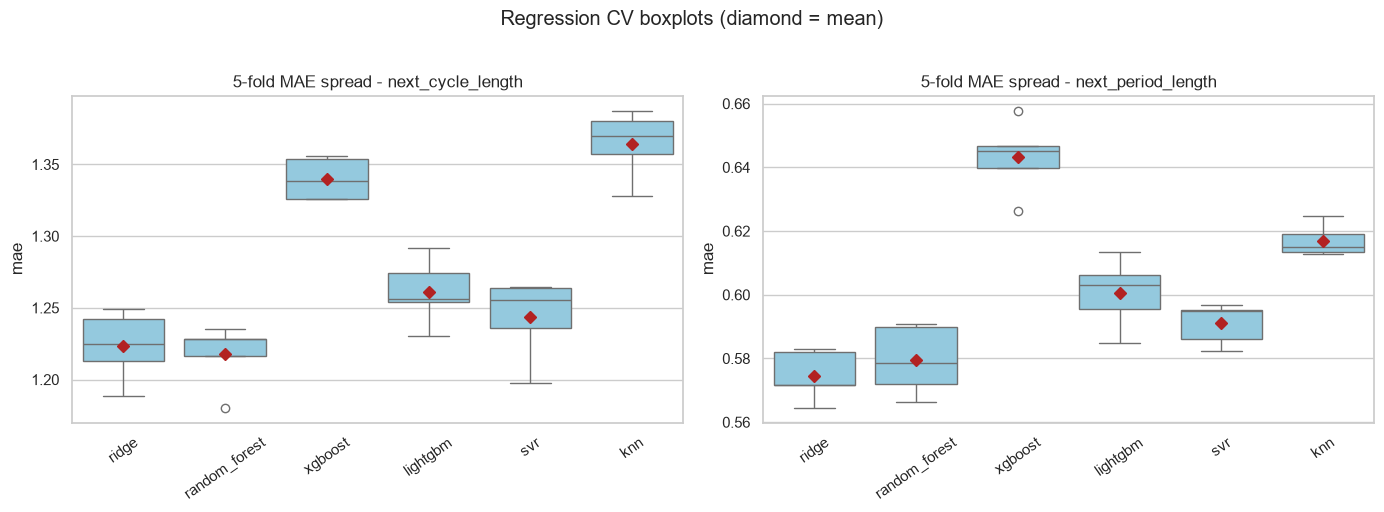

mean     std  cv_rel
target             model                                
next_cycle_length  knn            1.3645  0.0234  0.0171
                   lightgbm       1.2611  0.0231  0.0183
                   random_forest  1.2176  0.0219  0.0180
                   ridge          1.2235  0.0242  0.0198
                   svr            1.2434  0.0282  0.0227
                   xgboost        1.3399  0.0145  0.0108
next_period_length knn            0.6170  0.0049  0.0079
                   lightgbm       0.6006  0.0109  0.0181
                   random_forest  0.5795  0.0108  0.0187
                   ridge          0.5746  0.0078  0.0137
                   svr            0.5911  0.0064  0.0109
                   xgboost        0.6432  0.0115  0.0179

In [2]:
train = pd.read_csv(SPLITS_DIR / "train.csv")
X = train[FEATURES]
factories = reg_models()
rows = []
for target in TARGETS_REG:
    y = train[target]
    for name in REG_NAMES:
        folds = cv_regression_folds(factories[name], X, y)
        for i, m in enumerate(folds, 1):
            rows.append({"model": name, "target": target, "fold": i,
                         "mae": m["mae"], "rmse": m["rmse"], "r2": m["r2"]})
        print(target, name, "fold MAEs:", np.round([m["mae"] for m in folds], 3), flush=True)
fold_df = pd.DataFrame(rows)
fold_df.to_csv(RESULTS_DIR / "reg_fold_scores.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target in zip(axes, TARGETS_REG):
    sns.boxplot(data=fold_df[fold_df.target == target], x="model", y="mae", ax=ax,
                color="skyblue", showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "firebrick", "markeredgecolor": "firebrick"})
    ax.set_title(f"5-fold MAE spread - {target}")
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=35)
plt.suptitle("Regression CV boxplots (diamond = mean)", y=1.02)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "cv_boxplots_regression.png", dpi=150, bbox_inches="tight"); plt.show()

spread = (fold_df.groupby(["target", "model"])["mae"].agg(["mean", "std"])
          .assign(cv_rel=lambda d: d["std"] / d["mean"]).round(4))
display(spread)
